# Fine-tuned YOLO11x evaluation

This notebook checks the fine-tuned model, plots training curves, and runs the same video through the new weights.

In [1]:
from pathlib import Path
import os

PROJECT_ROOT = Path("/home/shiawase/ic8_ai/ad_detection")
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".cache/matplotlib"))

BASELINE_MODEL_PATH = PROJECT_ROOT / "models/trained/yolo11x_scratch_img1280/best.pt"
BASELINE_RESULTS_CSV = PROJECT_ROOT / "models/trained/yolo11x_scratch_img1280/results.csv"

FINETUNED_MODEL_PATH = PROJECT_ROOT / "models/trained/yolo11x_finetune_hard_negatives_v1/best.pt"
FINETUNED_RESULTS_CSV = PROJECT_ROOT / "models/trained/yolo11x_finetune_hard_negatives_v1/results.csv"
FINETUNED_RUN_DIR = PROJECT_ROOT / "runs/detect/ad_surface_v3/yolo11x_finetune_hard_negatives_v1"

VIDEO_PATH = PROJECT_ROOT / "test.mp4"
VIDEO_OUTPUT_DIR = PROJECT_ROOT / "runs/detect/ad_surface_video_finetune/test_yolo11x_finetune_detect25_show55"
VIDEO_OUTPUT_PATH = VIDEO_OUTPUT_DIR / "test_yolo11x_finetune_detect25_show55.mp4"
VIDEO_DETECTIONS_CSV = VIDEO_OUTPUT_DIR / "detections.csv"

PREDICT_CONF = 0.25
DISPLAY_CONF = 0.55
PREDICT_IOU = 0.70
IMG_SIZE = 1280
DEVICE = "0"

required_paths = [
    BASELINE_MODEL_PATH,
    BASELINE_RESULTS_CSV,
    FINETUNED_MODEL_PATH,
    FINETUNED_RESULTS_CSV,
    VIDEO_PATH,
]
for path in required_paths:
    print(f"{path}: {'OK' if path.exists() else 'MISSING'}")
assert all(path.exists() for path in required_paths), "One or more required paths are missing."

VIDEO_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Video output:", VIDEO_OUTPUT_PATH)
print("Detections CSV:", VIDEO_DETECTIONS_CSV)

/home/shiawase/ic8_ai/ad_detection/models/trained/yolo11x_scratch_img1280/best.pt: OK
/home/shiawase/ic8_ai/ad_detection/models/trained/yolo11x_scratch_img1280/results.csv: OK
/home/shiawase/ic8_ai/ad_detection/models/trained/yolo11x_finetune_hard_negatives_v1/best.pt: OK
/home/shiawase/ic8_ai/ad_detection/models/trained/yolo11x_finetune_hard_negatives_v1/results.csv: OK
/home/shiawase/ic8_ai/ad_detection/test.mp4: OK
Video output: /home/shiawase/ic8_ai/ad_detection/runs/detect/ad_surface_video_finetune/test_yolo11x_finetune_detect25_show55/test_yolo11x_finetune_detect25_show55.mp4
Detections CSV: /home/shiawase/ic8_ai/ad_detection/runs/detect/ad_surface_video_finetune/test_yolo11x_finetune_detect25_show55/detections.csv


## Training curves

In [2]:
from pathlib import Path
import os

PROJECT_ROOT = Path("/home/shiawase/ic8_ai/ad_detection")
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".cache/matplotlib"))

import pandas as pd
import matplotlib.pyplot as plt

BASELINE_RESULTS_CSV = PROJECT_ROOT / "models/trained/yolo11x_scratch_img1280/results.csv"
FINETUNED_RESULTS_CSV = PROJECT_ROOT / "models/trained/yolo11x_finetune_hard_negatives_v1/results.csv"

def read_yolo_results(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df.columns = [column.strip() for column in df.columns]
    if "epoch" not in df.columns:
        df.insert(0, "epoch", range(len(df)))
    return df

baseline_results = read_yolo_results(BASELINE_RESULTS_CSV)
finetuned_results = read_yolo_results(FINETUNED_RESULTS_CSV)

print("Baseline epochs:", len(baseline_results))
print("Fine-tune epochs:", len(finetuned_results))
display(finetuned_results.tail(10))

Baseline epochs: 150
Fine-tune epochs: 80


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
70,71,10873.5,0.42364,0.37818,0.89263,0.93042,0.90582,0.94739,0.84460,0.50189,0.51990,0.95991,0.000267,0.000267,0.000267
71,72,10979.7,0.42243,0.36698,0.86985,0.93593,0.89024,0.94664,0.84352,0.50041,0.48867,0.95354,0.000243,0.000243,0.000243
72,73,11087.0,0.41127,0.35664,0.87472,0.91803,0.90859,0.94829,0.84956,0.48479,0.48109,0.95287,0.000218,0.000218,0.000218
73,74,11202.4,0.41303,0.32982,0.86307,0.92247,0.88986,0.95080,0.84420,0.49193,0.47535,0.96159,0.000193,0.000193,0.000193
74,75,11314.1,0.39843,0.33310,0.85773,0.92771,0.89474,0.94944,0.84732,0.49056,0.47404,0.95675,0.000169,0.000169,0.000169
75,76,11422.5,0.37524,0.31488,0.84543,0.92294,0.89580,0.95120,0.84934,0.47888,0.48233,0.95213,0.000144,0.000144,0.000144
76,77,11534.7,0.40014,0.33582,0.87023,0.91638,0.91074,0.94854,0.84875,0.47803,0.47660,0.94672,0.000119,0.000119,0.000119
77,78,11644.0,0.39456,0.31530,0.86662,0.93646,0.88366,0.94773,0.85383,0.47470,0.48054,0.94898,0.000094,0.000094,0.000094
78,79,11751.7,0.38179,0.30899,0.85976,0.92830,0.89656,0.94850,0.85508,0.46838,0.47348,0.94423,0.000069,0.000069,0.000069
79,80,11858.5,0.37538,0.31140,0.84332,0.93153,0.89474,0.94688,0.85640,0.46429,0.47266,0.94219,0.000045,0.000045,0.000045


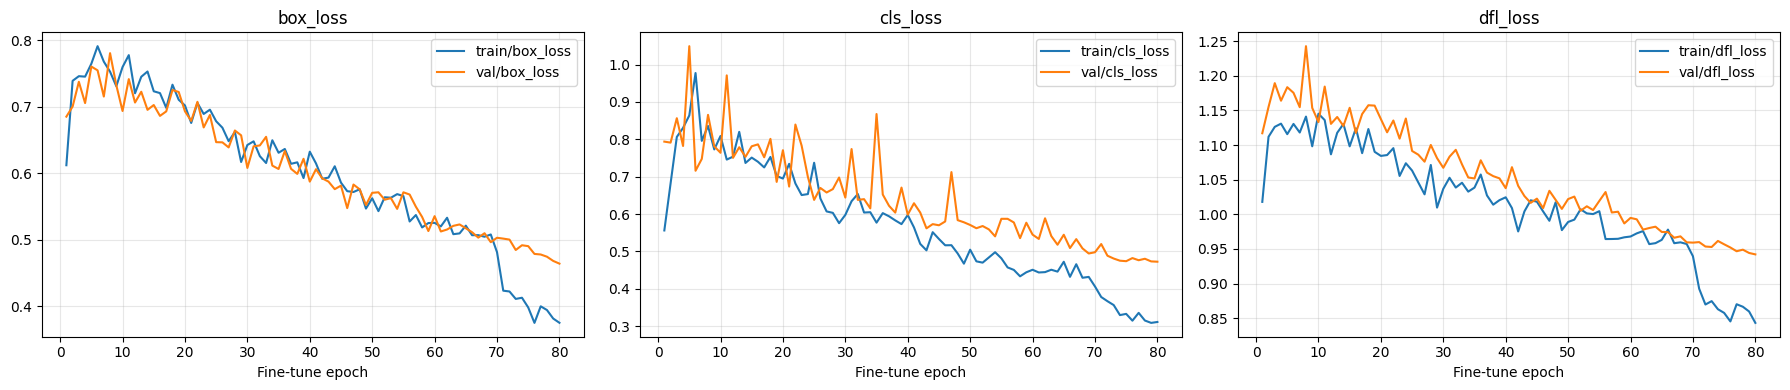

In [3]:
loss_pairs = [
    ("train/box_loss", "val/box_loss"),
    ("train/cls_loss", "val/cls_loss"),
    ("train/dfl_loss", "val/dfl_loss"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, (train_column, val_column) in zip(axes, loss_pairs):
    if train_column in finetuned_results.columns:
        ax.plot(finetuned_results["epoch"], finetuned_results[train_column], label=train_column)
    if val_column in finetuned_results.columns:
        ax.plot(finetuned_results["epoch"], finetuned_results[val_column], label=val_column)
    ax.set_title(train_column.split("/")[1])
    ax.set_xlabel("Fine-tune epoch")
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

,model,epochs,last_metrics/precision(B),best_metrics/precision(B),last_metrics/recall(B),best_metrics/recall(B),last_metrics/mAP50(B),best_metrics/mAP50(B),last_metrics/mAP50-95(B),best_metrics/mAP50-95(B)
0,baseline,150,0.93807,0.94578,0.88846,0.90823,0.94419,0.94848,0.83401,0.83401
1,finetuned,80,0.93153,0.94359,0.89474,0.92244,0.94688,0.95174,0.85640,0.85640


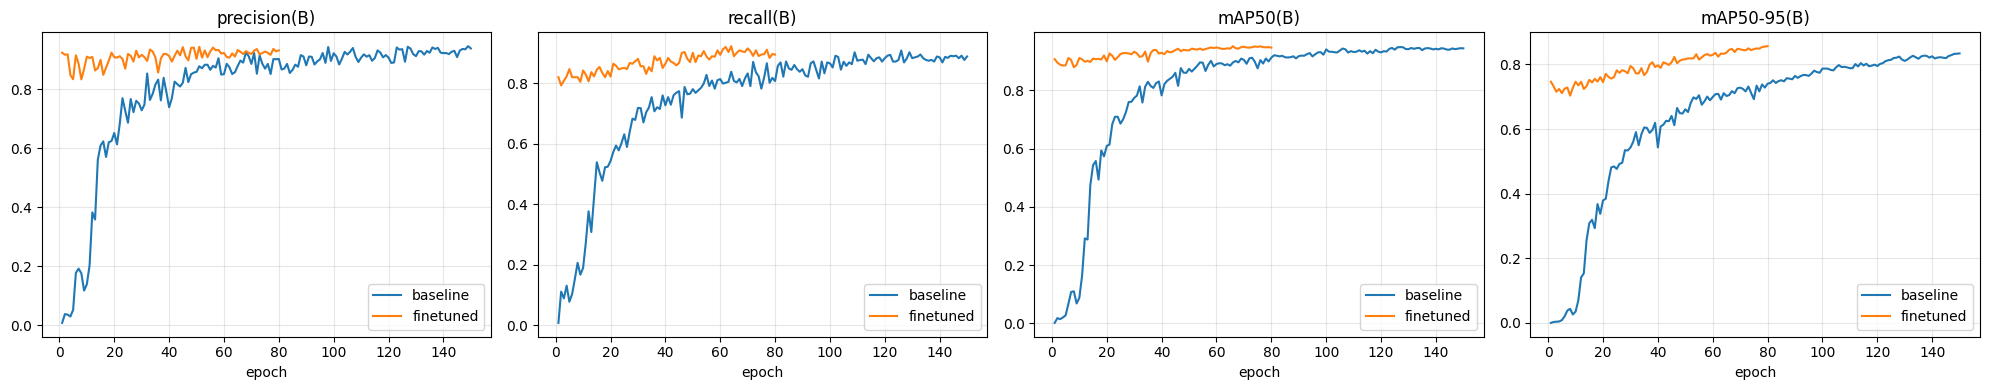

In [4]:
metric_columns = [
    "metrics/precision(B)",
    "metrics/recall(B)",
    "metrics/mAP50(B)",
    "metrics/mAP50-95(B)",
]
metric_columns = [column for column in metric_columns if column in finetuned_results.columns]

summary_rows = []
for label, df in [("baseline", baseline_results), ("finetuned", finetuned_results)]:
    row = {"model": label, "epochs": len(df)}
    for column in metric_columns:
        row[f"last_{column}"] = df[column].iloc[-1]
        row[f"best_{column}"] = df[column].max()
    summary_rows.append(row)

summary = pd.DataFrame(summary_rows)
display(summary)

fig, axes = plt.subplots(1, len(metric_columns), figsize=(5 * len(metric_columns), 4))
if len(metric_columns) == 1:
    axes = [axes]
for ax, column in zip(axes, metric_columns):
    ax.plot(baseline_results["epoch"], baseline_results[column], label="baseline")
    ax.plot(finetuned_results["epoch"], finetuned_results[column], label="finetuned")
    ax.set_title(column.replace("metrics/", ""))
    ax.set_xlabel("epoch")
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

/home/shiawase/ic8_ai/ad_detection/models/trained/yolo11x_finetune_hard_negatives_v1/results.png


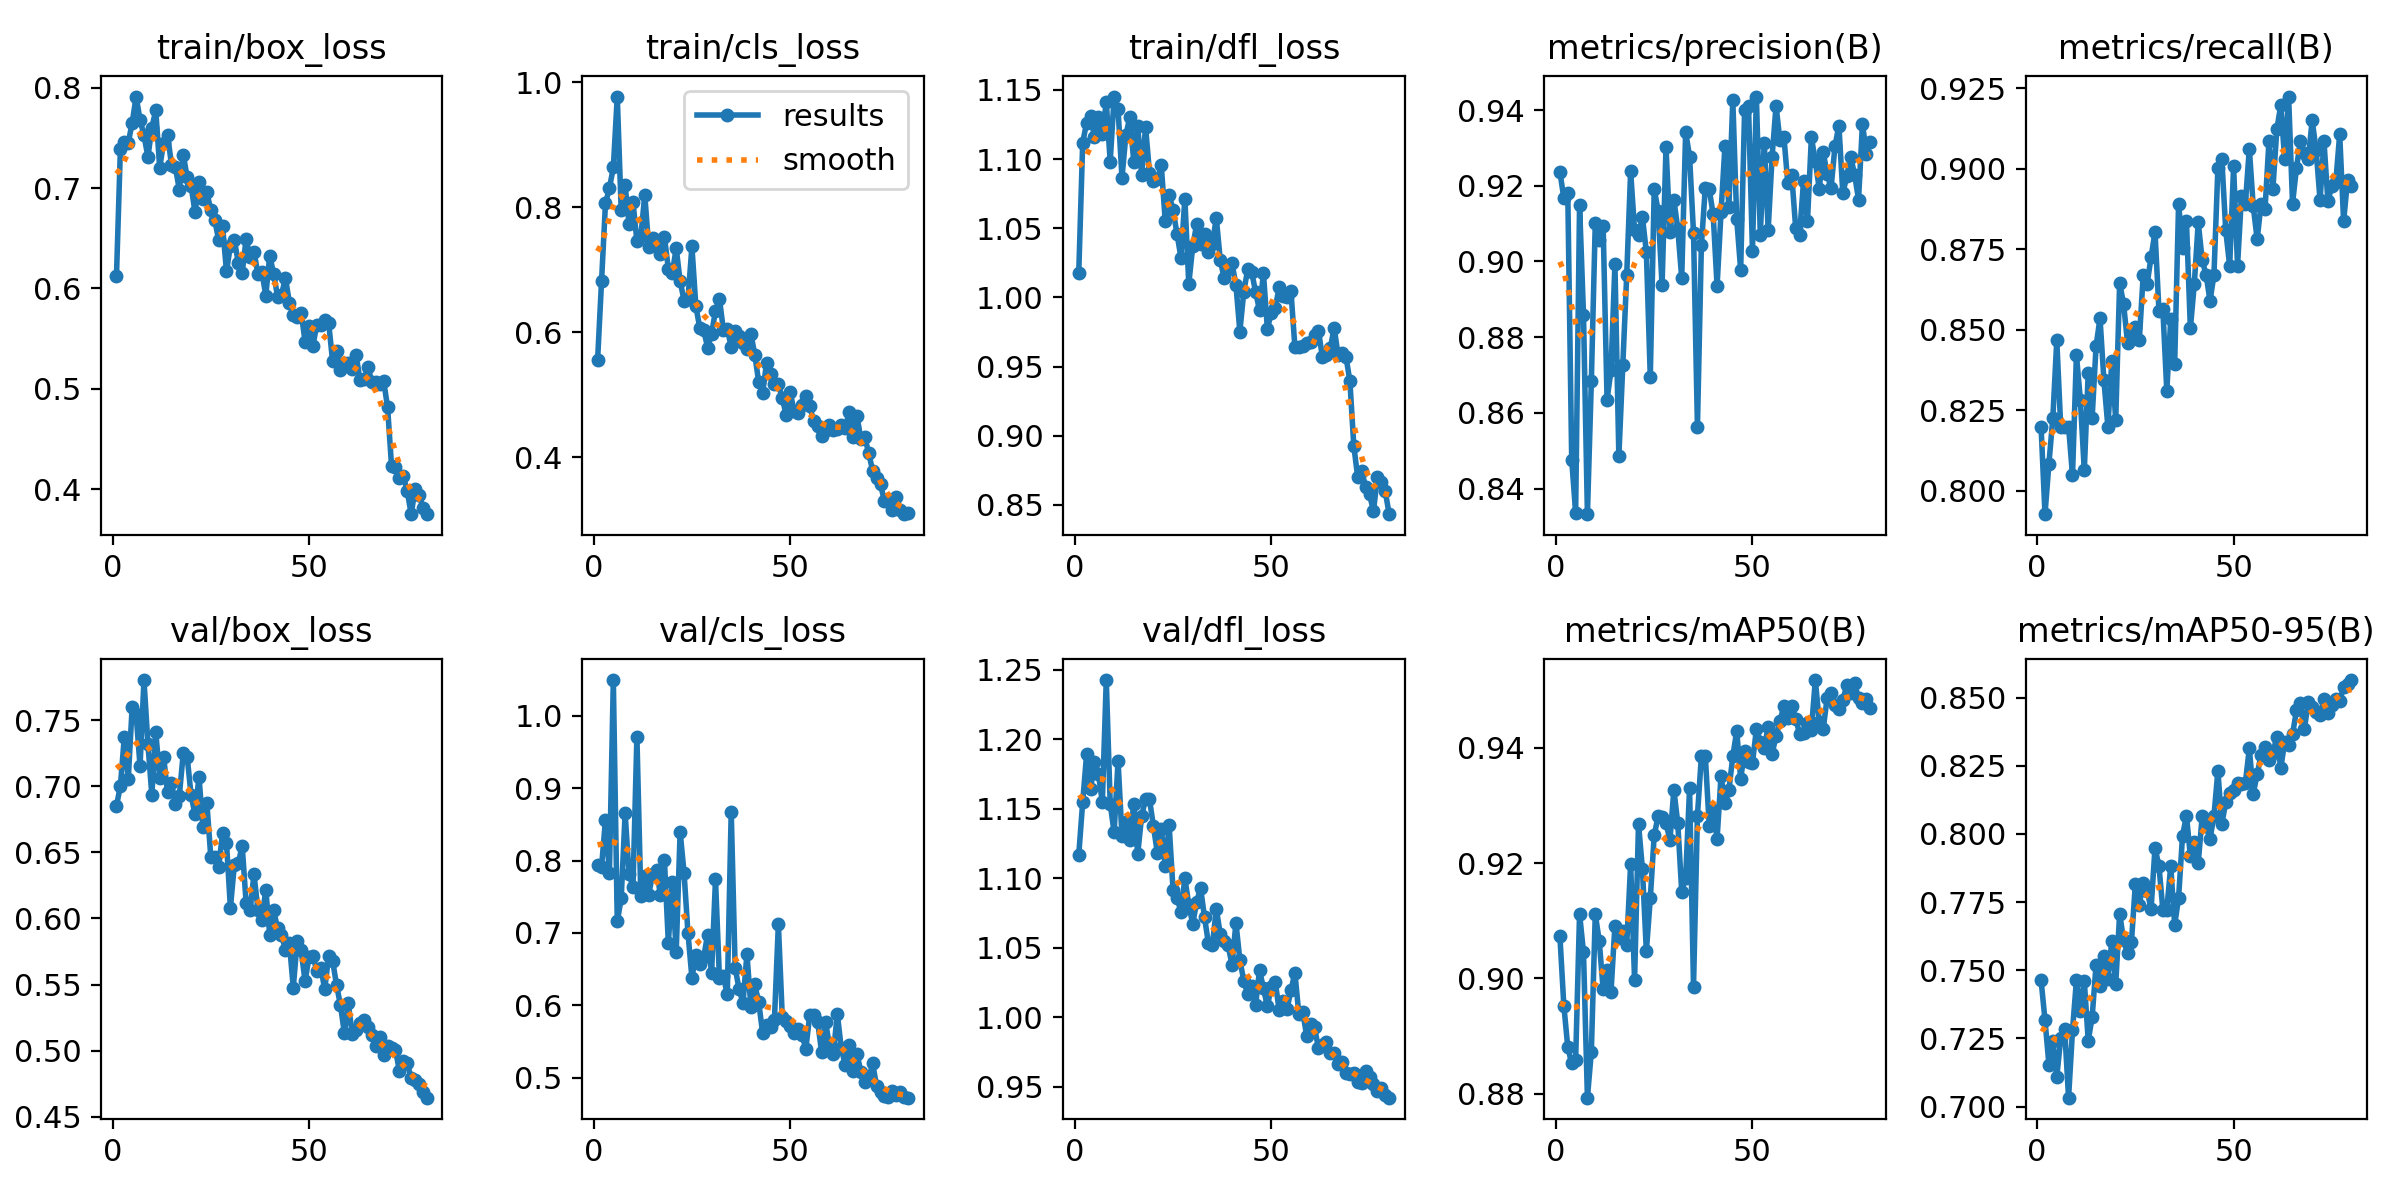

/home/shiawase/ic8_ai/ad_detection/models/trained/yolo11x_finetune_hard_negatives_v1/confusion_matrix_normalized.png


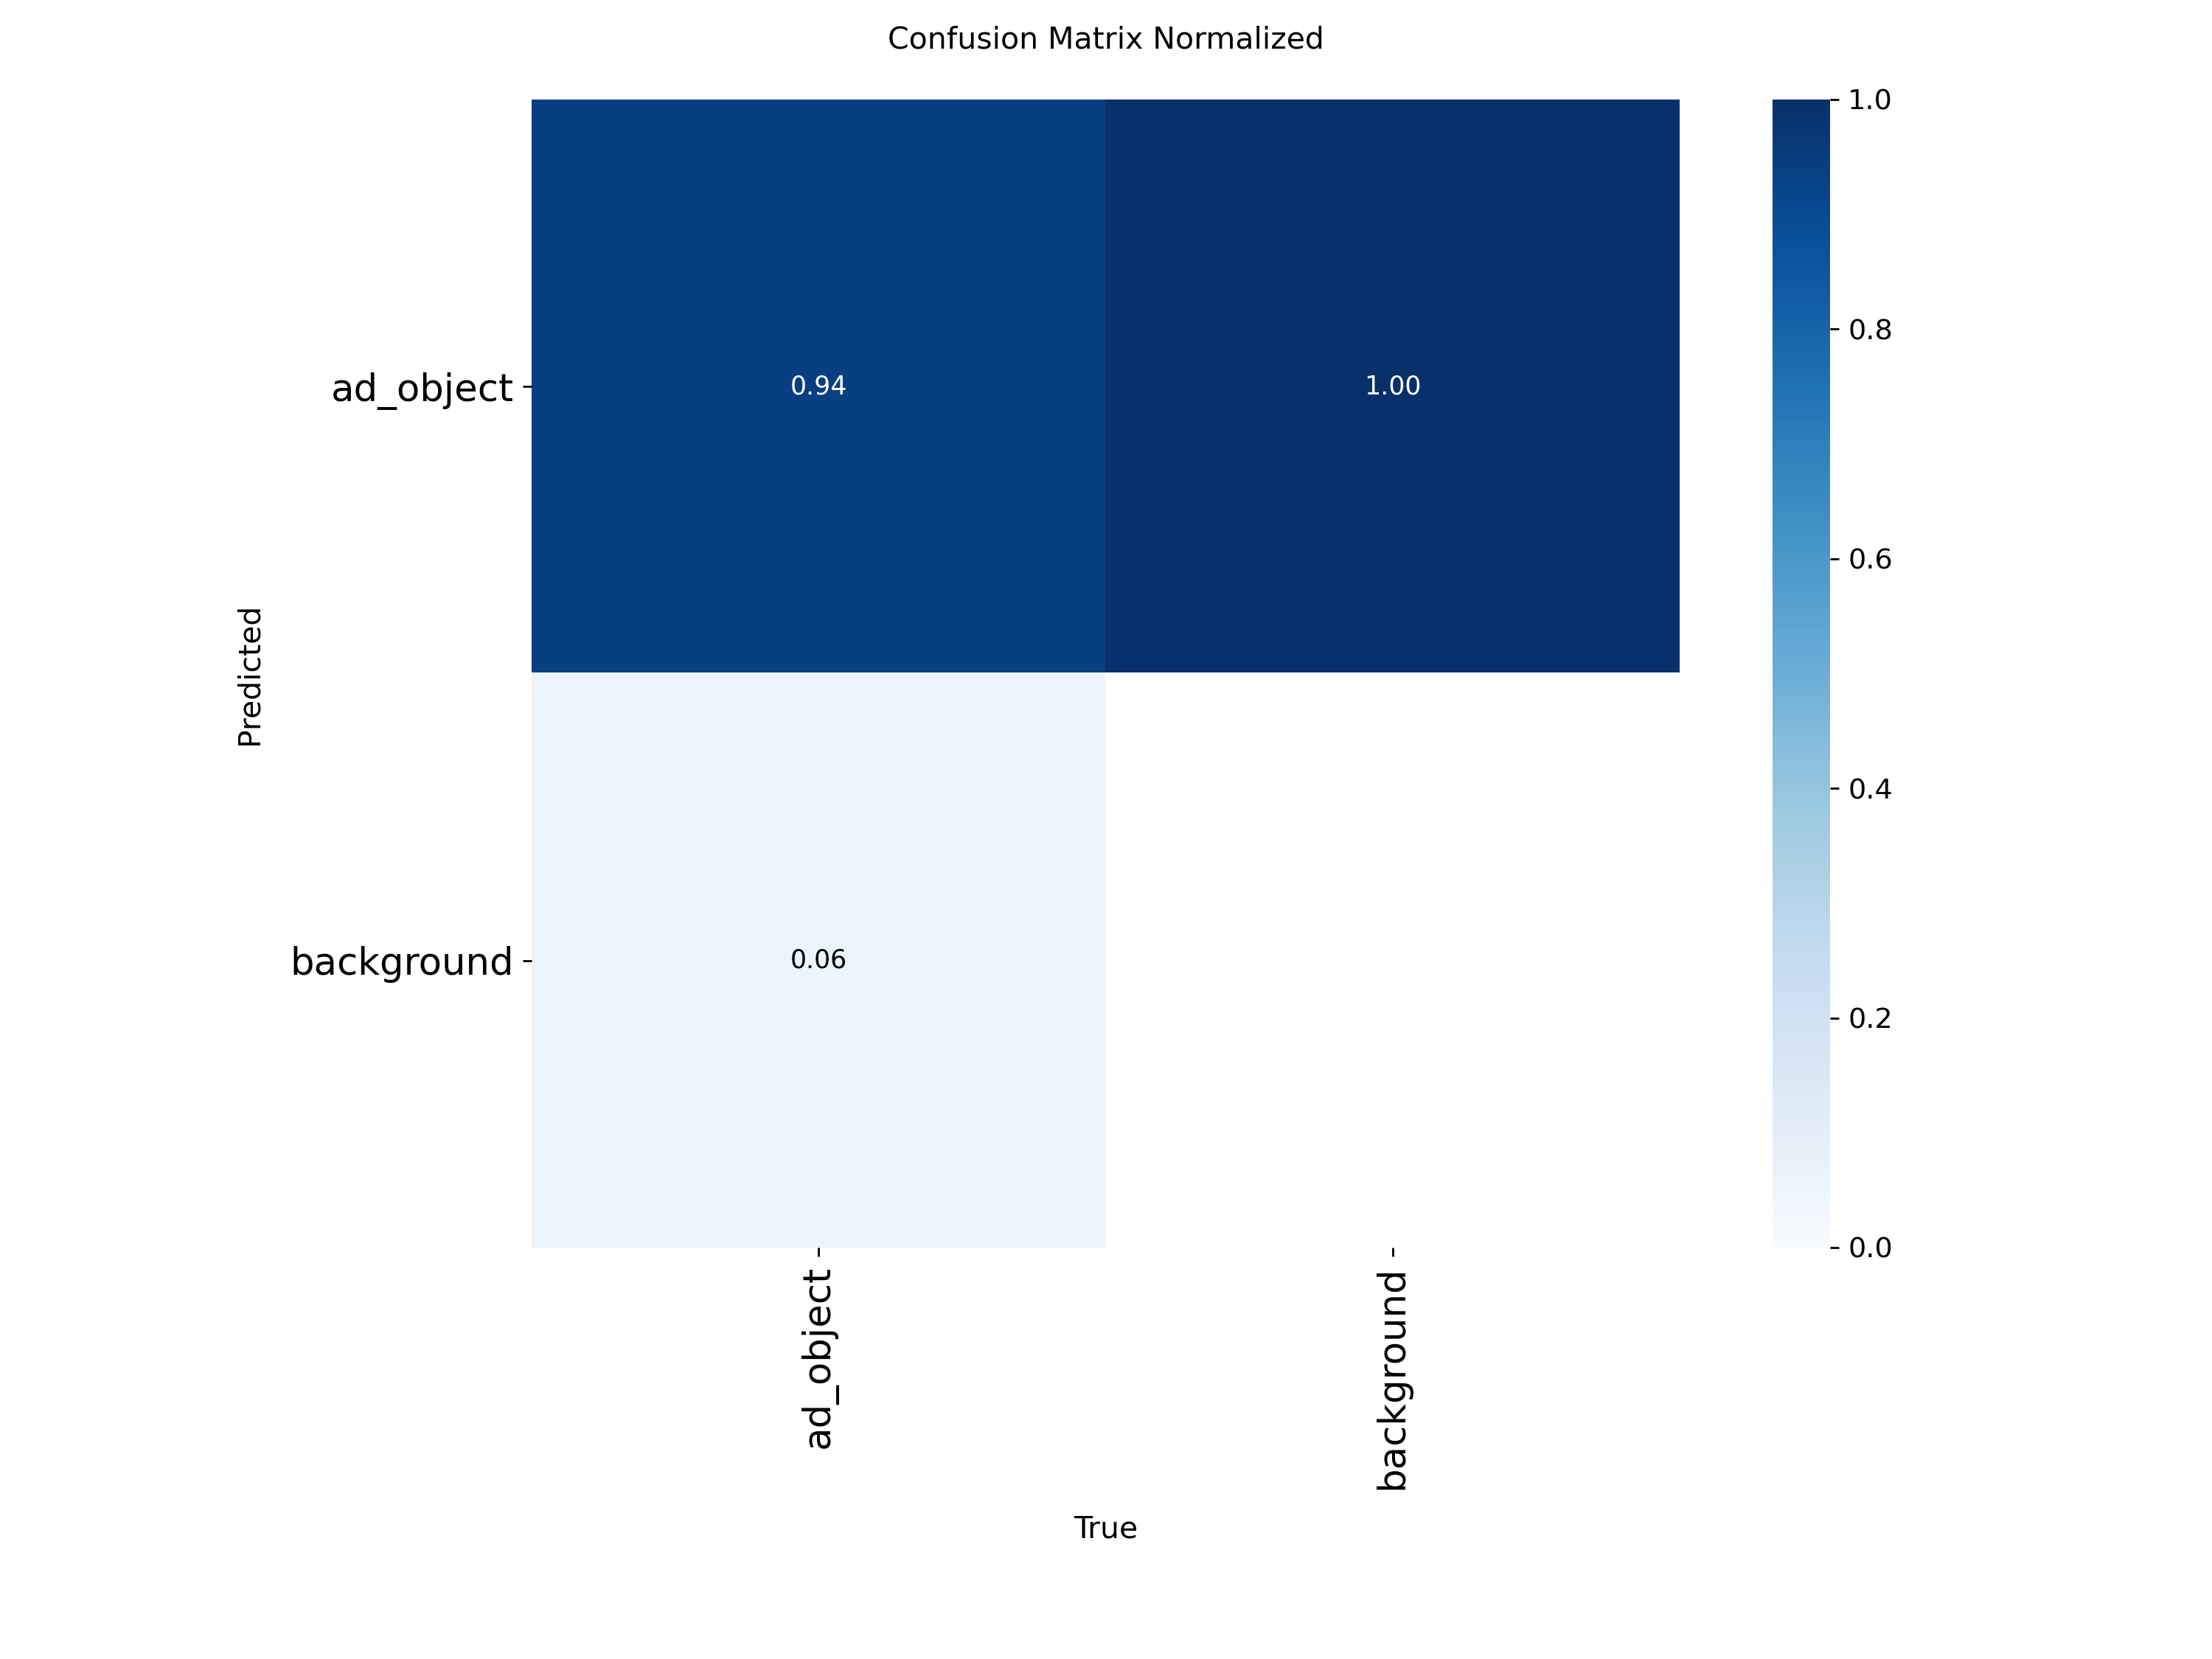

/home/shiawase/ic8_ai/ad_detection/models/trained/yolo11x_finetune_hard_negatives_v1/confusion_matrix.png


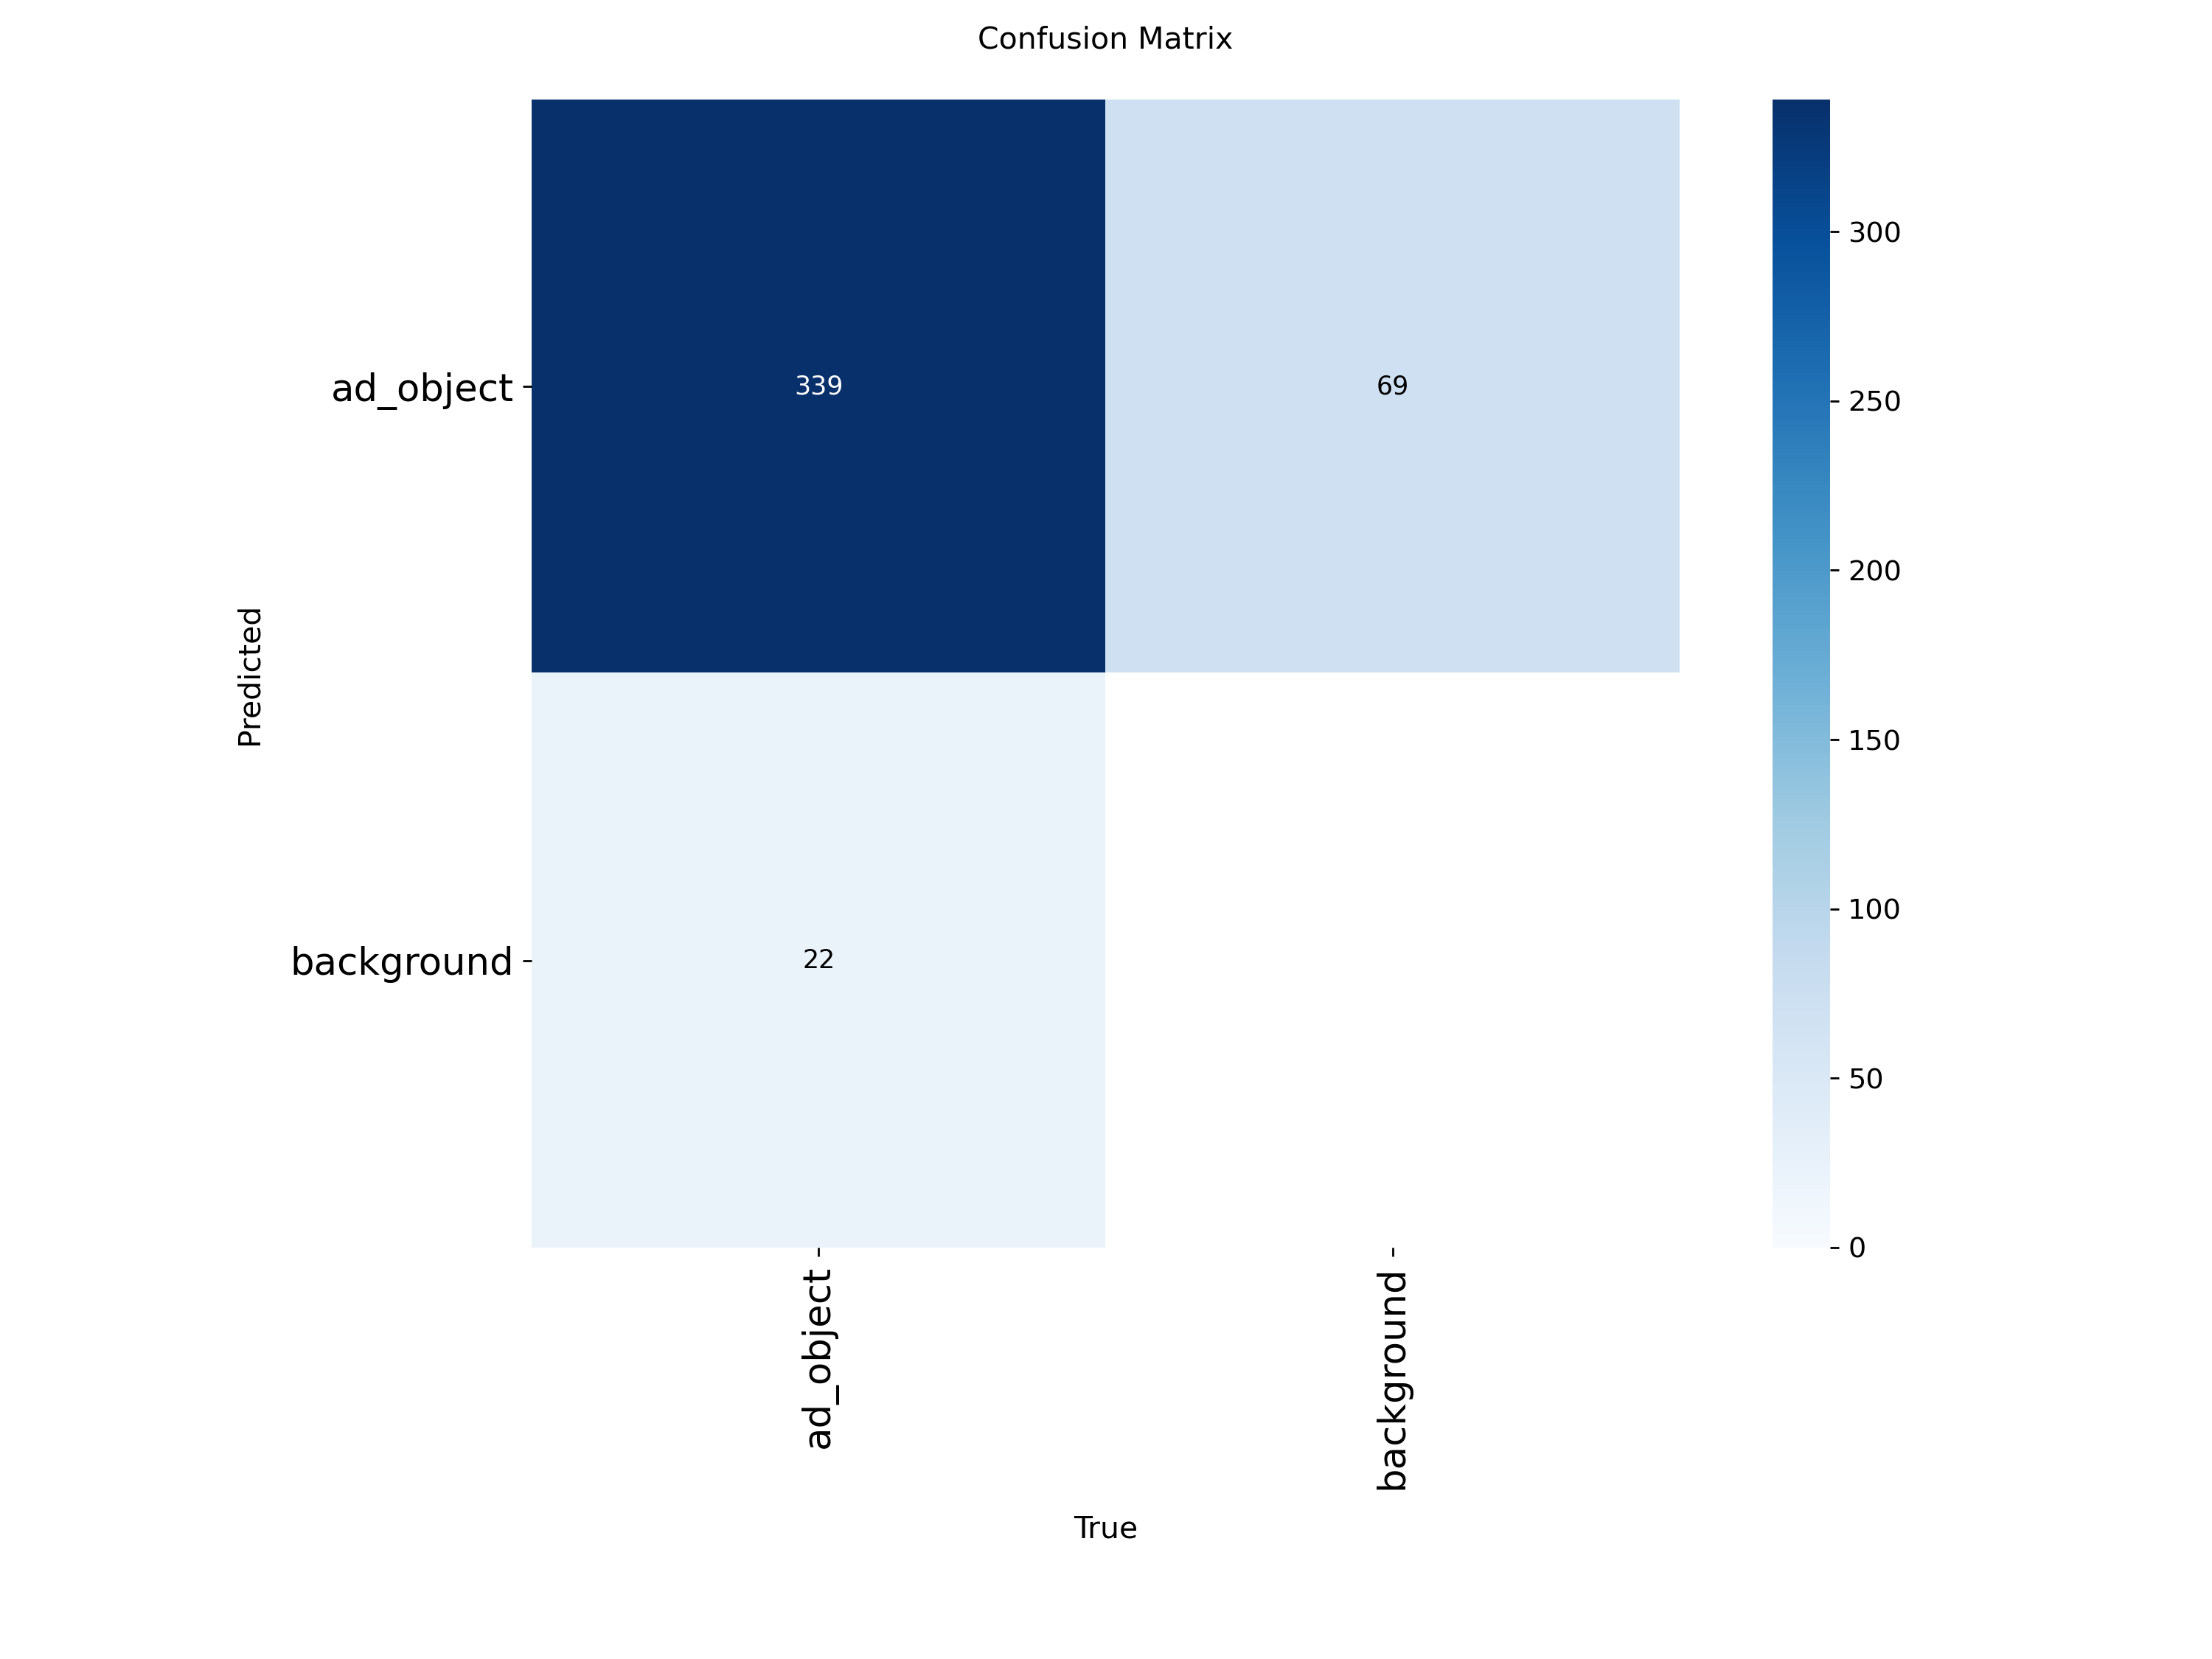

In [5]:
from IPython.display import Image, display
from pathlib import Path

PROJECT_ROOT = Path("/home/shiawase/ic8_ai/ad_detection")
FINETUNED_EXPORT_DIR = PROJECT_ROOT / "models/trained/yolo11x_finetune_hard_negatives_v1"

for image_name in ["results.png", "confusion_matrix_normalized.png", "confusion_matrix.png"]:
    image_path = FINETUNED_EXPORT_DIR / image_name
    if image_path.exists():
        print(image_path)
        display(Image(filename=str(image_path)))

## Video inference with fine-tuned weights

In [6]:
from pathlib import Path
import csv
import os
import time

PROJECT_ROOT = Path("/home/shiawase/ic8_ai/ad_detection")
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".cache/matplotlib"))

import cv2
from ultralytics import YOLO

MODEL_PATH = PROJECT_ROOT / "models/trained/yolo11x_finetune_hard_negatives_v1/best.pt"
VIDEO_PATH = PROJECT_ROOT / "test.mp4"
OUTPUT_DIR = PROJECT_ROOT / "runs/detect/ad_surface_video_finetune/test_yolo11x_finetune_detect25_show55"
OUTPUT_VIDEO_PATH = OUTPUT_DIR / "test_yolo11x_finetune_detect25_show55.mp4"
OUTPUT_CSV_PATH = OUTPUT_DIR / "detections.csv"

PREDICT_CONF = 0.25
DISPLAY_CONF = 0.55
PREDICT_IOU = 0.70
IMG_SIZE = 1280
DEVICE = "0"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
assert MODEL_PATH.exists(), MODEL_PATH
assert VIDEO_PATH.exists(), VIDEO_PATH

cap = cv2.VideoCapture(str(VIDEO_PATH))
if not cap.isOpened():
    raise RuntimeError(f"Could not open video: {VIDEO_PATH}")

fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(str(OUTPUT_VIDEO_PATH), fourcc, fps, (width, height))
if not writer.isOpened():
    cap.release()
    raise RuntimeError(f"Could not create output video: {OUTPUT_VIDEO_PATH}")

model = YOLO(str(MODEL_PATH))
class_names = model.names

def class_label(class_id: int) -> str:
    if isinstance(class_names, dict):
        return str(class_names.get(class_id, class_id))
    if isinstance(class_names, (list, tuple)) and 0 <= class_id < len(class_names):
        return str(class_names[class_id])
    return str(class_id)

rows = []
frame_index = 0
started_at = time.time()

while True:
    ok, frame = cap.read()
    if not ok:
        break

    result = model.predict(
        source=frame,
        imgsz=IMG_SIZE,
        conf=PREDICT_CONF,
        iou=PREDICT_IOU,
        device=DEVICE,
        verbose=False,
    )[0]

    if result.boxes is not None:
        for box_index, box in enumerate(result.boxes):
            x1, y1, x2, y2 = [float(value) for value in box.xyxy[0].tolist()]
            confidence = float(box.conf[0])
            class_id = int(box.cls[0])
            displayed = confidence >= DISPLAY_CONF

            rows.append({
                "frame": frame_index,
                "time_sec": frame_index / fps,
                "box_index": box_index,
                "class_id": class_id,
                "class_name": class_label(class_id),
                "confidence": confidence,
                "displayed": int(displayed),
                "x1": x1,
                "y1": y1,
                "x2": x2,
                "y2": y2,
                "width": x2 - x1,
                "height": y2 - y1,
            })

            if displayed:
                left, top, right, bottom = map(round, (x1, y1, x2, y2))
                label = f"{class_label(class_id)} {confidence:.2f}"
                cv2.rectangle(frame, (left, top), (right, bottom), (0, 0, 255), 3)
                cv2.putText(
                    frame,
                    label,
                    (left, max(top - 8, 24)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.8,
                    (0, 0, 255),
                    2,
                    cv2.LINE_AA,
                )

    writer.write(frame)
    frame_index += 1
    if frame_index % 100 == 0:
        print(f"Processed {frame_index}/{frame_count} frames")

cap.release()
writer.release()

fieldnames = [
    "frame",
    "time_sec",
    "box_index",
    "class_id",
    "class_name",
    "confidence",
    "displayed",
    "x1",
    "y1",
    "x2",
    "y2",
    "width",
    "height",
]
with OUTPUT_CSV_PATH.open("w", newline="", encoding="utf-8") as file:
    writer_csv = csv.DictWriter(file, fieldnames=fieldnames)
    writer_csv.writeheader()
    writer_csv.writerows(rows)

elapsed = time.time() - started_at
displayed_count = sum(row["displayed"] for row in rows)
print("Done")
print("Frames:", frame_index)
print("All detections >=", PREDICT_CONF, ":", len(rows))
print("Displayed detections >=", DISPLAY_CONF, ":", displayed_count)
print("Elapsed sec:", round(elapsed, 1))
print("Output video:", OUTPUT_VIDEO_PATH)
print("Output CSV:", OUTPUT_CSV_PATH)

Processed 100/11182 frames
Processed 200/11182 frames
Processed 300/11182 frames
Processed 400/11182 frames
Processed 500/11182 frames
Processed 600/11182 frames
Processed 700/11182 frames
Processed 800/11182 frames
Processed 900/11182 frames
Processed 1000/11182 frames
Processed 1100/11182 frames
Processed 1200/11182 frames
Processed 1300/11182 frames
Processed 1400/11182 frames
Processed 1500/11182 frames
Processed 1600/11182 frames
Processed 1700/11182 frames
Processed 1800/11182 frames
Processed 1900/11182 frames
Processed 2000/11182 frames
Processed 2100/11182 frames
Processed 2200/11182 frames
Processed 2300/11182 frames
Processed 2400/11182 frames
Processed 2500/11182 frames
Processed 2600/11182 frames
Processed 2700/11182 frames
Processed 2800/11182 frames
Processed 2900/11182 frames
Processed 3000/11182 frames
Processed 3100/11182 frames
Processed 3200/11182 frames
Processed 3300/11182 frames
Processed 3400/11182 frames
Processed 3500/11182 frames
Processed 3600/11182 frames
P

In [7]:
from pathlib import Path
import pandas as pd
from IPython.display import Video, display

PROJECT_ROOT = Path("/home/shiawase/ic8_ai/ad_detection")
OUTPUT_DIR = PROJECT_ROOT / "runs/detect/ad_surface_video_finetune/test_yolo11x_finetune_detect25_show55"
OUTPUT_VIDEO_PATH = OUTPUT_DIR / "test_yolo11x_finetune_detect25_show55.mp4"
OUTPUT_CSV_PATH = OUTPUT_DIR / "detections.csv"

if OUTPUT_CSV_PATH.exists():
    detections = pd.read_csv(OUTPUT_CSV_PATH)
    display(detections.describe(include="all"))
    display(detections.head(20))

if OUTPUT_VIDEO_PATH.exists():
    display(Video(str(OUTPUT_VIDEO_PATH), embed=False))

,frame,time_sec,box_index,class_id,class_name,confidence,displayed,x1,y1,x2,y2,width,height
count,3614.000000,3614.000000,3614.000000,3614.0,3614,3614.000000,3614.000000,3614.000000,3614.000000,3614.000000,3614.000000,3614.000000,3614.000000
unique,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,ad_object,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,3614,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,4391.459325,146.417449,0.410349,0.0,NaN,0.725331,0.793304,374.380411,591.964737,473.637087,729.915297,99.256676,137.950561
std,2697.281861,89.931183,0.627899,0.0,NaN,0.194994,0.404992,54.717731,272.984027,78.594676,294.117656,68.509463,88.517590
min,178.000000,5.934771,0.000000,0.0,NaN,0.250085,0.000000,0.000000,0.000000,236.358582,18.026236,13.630188,17.736271
25%,1994.250000,66.491108,0.000000,0.0,NaN,0.610531,1.000000,366.037018,429.514603,434.118210,507.474045,64.481506,75.060318
50%,4281.000000,142.734580,0.000000,0.0,NaN,0.800102,1.000000,370.037552,592.078308,438.978806,741.959106,71.648193,144.805607
75%,5813.750000,193.838627,1.000000,0.0,NaN,0.874918,1.000000,388.396454,799.228760,497.663696,980.701981,112.771057,181.706909


,frame,time_sec,box_index,class_id,class_name,confidence,displayed,x1,y1,x2,y2,width,height
0,178,5.934771,0,0,ad_object,0.333464,0,0.000000,13.734039,720.000000,395.602295,720.000000,381.868256
1,576,19.204653,0,0,ad_object,0.263159,0,135.085327,1178.960083,593.997803,1279.150269,458.912476,100.190186
2,580,19.338018,0,0,ad_object,0.422260,0,145.426819,1247.612061,314.986267,1279.460693,169.559448,31.848633
3,590,19.671432,0,0,ad_object,0.478349,0,301.119385,375.396973,367.007935,441.488770,65.888550,66.091797
4,591,19.704774,0,0,ad_object,0.425659,0,301.437378,373.739929,366.475220,440.579529,65.037842,66.839600
5,593,19.771457,0,0,ad_object,0.353498,0,299.795837,373.887634,366.162415,440.871826,66.366577,66.984192
6,604,20.138212,0,0,ad_object,0.302736,0,294.783508,379.362610,368.164368,447.680176,73.380859,68.317566
7,774,25.806252,0,0,ad_object,0.272250,0,344.675110,1160.161865,602.221924,1278.053467,257.546814,117.891602
8,805,26.839836,0,0,ad_object,0.293858,0,479.746918,1180.008789,493.377106,1216.975586,13.630188,36.966797
9,827,27.573347,0,0,ad_object,0.361714,0,245.964905,876.378662,265.981384,937.167725,20.016479,60.789062


## Export remaining displayed detections for CVAT review

In [ ]:
from pathlib import Path
import shutil
from zipfile import ZipFile, ZIP_STORED
import xml.etree.ElementTree as ET

import cv2
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path("/home/shiawase/ic8_ai/ad_detection")
VIDEO_PATH = PROJECT_ROOT / "test.mp4"
DETECTIONS_CSV = PROJECT_ROOT / "runs/detect/ad_surface_video_finetune/test_yolo11x_finetune_detect25_show55/detections.csv"

CVAT_EXPORT_DIR = PROJECT_ROOT / "cvat_import/video_finetune_fp_review_events"
CVAT_IMAGES_DIR = CVAT_EXPORT_DIR / "images"
CVAT_ZIP_PATH = CVAT_EXPORT_DIR / "images.zip"
CVAT_XML_PATH = CVAT_EXPORT_DIR / "annotations.xml"
CVAT_MANIFEST_PATH = CVAT_EXPORT_DIR / "frame_manifest.csv"
CVAT_SELECTED_DETECTIONS_CSV = CVAT_EXPORT_DIR / "selected_detections.csv"

CVAT_LABEL_NAME = "ad_object"
CVAT_FRAME_PREFIX = "finetune_fp"
CVAT_MIN_CONF = 0.55
CVAT_ONLY_DISPLAYED = True
CVAT_EVENT_GAP = 90
CVAT_FRAMES_PER_EVENT = 3
CVAT_MAX_FRAMES = 120
CVAT_CLEAN_OUTPUT = True

assert VIDEO_PATH.exists(), VIDEO_PATH
assert DETECTIONS_CSV.exists(), DETECTIONS_CSV

if CVAT_CLEAN_OUTPUT and CVAT_EXPORT_DIR.exists():
    shutil.rmtree(CVAT_EXPORT_DIR)
CVAT_IMAGES_DIR.mkdir(parents=True, exist_ok=True)

detections = pd.read_csv(DETECTIONS_CSV)
detections = detections[detections["confidence"] >= CVAT_MIN_CONF].copy()
if CVAT_ONLY_DISPLAYED and "displayed" in detections.columns:
    detections = detections[detections["displayed"].astype(int) == 1].copy()

detections["frame"] = detections["frame"].astype(int)
candidate_frames = sorted(detections["frame"].unique().tolist())

def pick_evenly(values: list[int], count: int) -> list[int]:
    if count >= len(values):
        return values
    if count <= 1:
        return [values[len(values) // 2]]
    step = (len(values) - 1) / (count - 1)
    indexes = sorted({round(index * step) for index in range(count)})
    return [values[index] for index in indexes]

segments = []
current_segment = []
for frame_index in candidate_frames:
    if not current_segment or frame_index - current_segment[-1] <= CVAT_EVENT_GAP:
        current_segment.append(frame_index)
    else:
        segments.append(current_segment)
        current_segment = [frame_index]
if current_segment:
    segments.append(current_segment)

selected_frames = []
for segment in segments:
    selected_frames.extend(pick_evenly(segment, min(CVAT_FRAMES_PER_EVENT, len(segment))))

if CVAT_MAX_FRAMES is not None and len(selected_frames) > CVAT_MAX_FRAMES:
    selected_frames = pick_evenly(selected_frames, CVAT_MAX_FRAMES)

if not selected_frames:
    raise RuntimeError("No frames selected for CVAT export. Lower CVAT_MIN_CONF or disable CVAT_ONLY_DISPLAYED.")

def append_text(parent: ET.Element, tag: str, text: object) -> ET.Element:
    child = ET.SubElement(parent, tag)
    child.text = str(text)
    return child

def build_cvat_xml(frame_rows: list[dict], boxes_by_image: dict[str, pd.DataFrame]) -> ET.ElementTree:
    annotations = ET.Element("annotations")
    append_text(annotations, "version", "1.1")

    meta = ET.SubElement(annotations, "meta")
    task = ET.SubElement(meta, "task")
    append_text(task, "id", 0)
    append_text(task, "name", "video_finetune_fp_review_events")
    append_text(task, "size", len(frame_rows))
    append_text(task, "mode", "annotation")
    append_text(task, "overlap", 0)
    append_text(task, "bugtracker", "")
    append_text(task, "flipped", False)

    labels = ET.SubElement(task, "labels")
    label = ET.SubElement(labels, "label")
    append_text(label, "name", CVAT_LABEL_NAME)
    append_text(label, "color", "#ff0000")
    append_text(label, "type", "rectangle")
    ET.SubElement(label, "attributes")

    for image_id, frame_row in enumerate(frame_rows):
        image_name = frame_row["image_name"]
        image = ET.SubElement(
            annotations,
            "image",
            id=str(image_id),
            name=image_name,
            width=str(frame_row["width"]),
            height=str(frame_row["height"]),
        )
        for _, detection in boxes_by_image[image_name].iterrows():
            width = float(frame_row["width"])
            height = float(frame_row["height"])
            xtl = max(0.0, min(float(detection["x1"]), width - 1.0))
            ytl = max(0.0, min(float(detection["y1"]), height - 1.0))
            xbr = max(0.0, min(float(detection["x2"]), width - 1.0))
            ybr = max(0.0, min(float(detection["y2"]), height - 1.0))
            if xbr <= xtl or ybr <= ytl:
                continue
            ET.SubElement(
                image,
                "box",
                label=CVAT_LABEL_NAME,
                source="auto",
                occluded="0",
                xtl=f"{xtl:.2f}",
                ytl=f"{ytl:.2f}",
                xbr=f"{xbr:.2f}",
                ybr=f"{ybr:.2f}",
                z_order="0",
            )

    ET.indent(annotations, space="  ")
    return ET.ElementTree(annotations)

cap = cv2.VideoCapture(str(VIDEO_PATH))
if not cap.isOpened():
    raise RuntimeError(f"Could not open video: {VIDEO_PATH}")

fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
frame_rows = []
boxes_by_image = {}

for output_index, frame_index in enumerate(selected_frames, start=1):
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
    ok, frame = cap.read()
    if not ok:
        print(f"Skip unreadable frame: {frame_index}")
        continue

    image_name = f"{CVAT_FRAME_PREFIX}_{output_index:06d}.jpg"
    image_path = CVAT_IMAGES_DIR / image_name
    height, width = frame.shape[:2]
    cv2.imwrite(str(image_path), frame, [cv2.IMWRITE_JPEG_QUALITY, 95])

    frame_detections = detections[detections["frame"] == frame_index].copy()
    frame_detections.insert(0, "image_name", image_name)
    boxes_by_image[image_name] = frame_detections

    frame_rows.append({
        "image_name": image_name,
        "source_frame": frame_index,
        "source_time_sec": frame_index / fps,
        "width": width,
        "height": height,
        "box_count": len(frame_detections),
        "max_confidence": frame_detections["confidence"].max(),
    })

cap.release()

if not frame_rows:
    raise RuntimeError("No frames were exported.")

xml_tree = build_cvat_xml(frame_rows, boxes_by_image)
xml_tree.write(CVAT_XML_PATH, encoding="utf-8", xml_declaration=True)

with ZipFile(CVAT_ZIP_PATH, "w", compression=ZIP_STORED) as zip_file:
    for frame_row in frame_rows:
        image_path = CVAT_IMAGES_DIR / frame_row["image_name"]
        zip_file.write(image_path, arcname=frame_row["image_name"])

manifest = pd.DataFrame(frame_rows)
manifest.to_csv(CVAT_MANIFEST_PATH, index=False)
selected_detections = pd.concat(boxes_by_image.values(), ignore_index=True)
selected_detections.to_csv(CVAT_SELECTED_DETECTIONS_CSV, index=False)

print("Candidate frames:", len(candidate_frames))
print("Detection segments:", len(segments))
print("Frames exported:", len(frame_rows))
print("Boxes exported:", len(selected_detections))
print("Images zip:", CVAT_ZIP_PATH)
print("Annotations XML:", CVAT_XML_PATH)
print("Manifest:", CVAT_MANIFEST_PATH)
display(manifest.head(20))

In [ ]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path("/home/shiawase/ic8_ai/ad_detection")
CVAT_EXPORT_DIR = PROJECT_ROOT / "cvat_import/video_finetune_fp_review_events"
CVAT_MANIFEST_PATH = CVAT_EXPORT_DIR / "frame_manifest.csv"
CVAT_SELECTED_DETECTIONS_CSV = CVAT_EXPORT_DIR / "selected_detections.csv"

print("Upload images when creating CVAT task:", CVAT_EXPORT_DIR / "images.zip")
print("Import annotations after task creation:", CVAT_EXPORT_DIR / "annotations.xml")
print("Import format: CVAT for images 1.1")

if CVAT_MANIFEST_PATH.exists():
    display(pd.read_csv(CVAT_MANIFEST_PATH).head(20))
if CVAT_SELECTED_DETECTIONS_CSV.exists():
    display(pd.read_csv(CVAT_SELECTED_DETECTIONS_CSV).head(20))